In [ ]:
import numpy as np
import pandas as pd
import re
import string
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Embedding, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, recall_score, precision_score, accuracy_score
from google.colab import drive

# -----------------------------------------------------------
# 1. إعدادات المسار (مهم جداً)
# -----------------------------------------------------------
drive.mount('/content/drive')

# غير 'MyProject' باسم المجلد الموجود عندك في الدرايف
BASE_PATH = '/content/drive/MyDrive/data/'

if not os.path.exists(BASE_PATH):
    raise FileNotFoundError(f"❌ المجلد غير موجود: {BASE_PATH}. تأكد من إنشاء المجلد في الدرايف.")
else:
    print(f"✅ تم تحديد المسار: {BASE_PATH}")


Mounted at /content/drive
✅ تم تحديد المسار: /content/drive/MyDrive/data/


In [ ]:
# -----------------------------------------------------------
# إعدادات المسار (تأكد أين تشغل الكود)
# -----------------------------------------------------------
# -----------------------------------------------------------
# 1. إعداد قائمة الملفات (DATASETS CONFIGURATION)
# -----------------------------------------------------------
DATASETS_CONFIG = [
    {
        'file_name': 'Final_Combined_Data.xlsx',   # ملفك الأساسي
        # هنا نضع الأسماء الطويلة كما هي في ملفك بالضبط
        'text_col': 'حدثنا عن تجربتك مع التعليم الإلكتروني، ما هي أكثر الأشياء التي أعجبتك وأكثر المشاكل التي واجهتها؟',
        'label_col': 'بناءً على تجربتك الكاملة، ما هو تقييمك العام لنظام التعليم الإلكتروني؟',
        'mapping': None
    },
    # --- إذا كان لديك ملف آخر (مثل HARD أو غيره) أضفه هنا، وإلا اترك هذا الجزء تعليقاً ---
    # {
    #     'file_name': 'Another_Dataset.csv',
    #     'text_col': 'review',
    #     'label_col': 'rating',
    #     'mapping': {'Positive': 2, 'Negative': 0, 'Neutral': 1}
    # },
]



In [ ]:
# -----------------------------------------------------------
# 2. دوال التنظيف والمعالجة
# -----------------------------------------------------------
def clean_arabic_text(text):
    text = str(text)
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', "", text)
    text = re.sub("[أإآ]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub(r'\d+', '', text)
    translator = str.maketrans('', '', string.punctuation + '،؛؟')
    text = text.translate(translator)
    return " ".join(text.split())

DEFAULT_MAPPING = {
    'سيء جداً': 0, 'سيء': 0, 'سلبي': 0, 'غير راضي': 0, 'bad': 0,
    'متوسط': 1, 'محايد': 1, 'عادي': 1, 'neutral': 1,
    'ممتاز': 2, 'جيد جداً': 2, 'جيد': 2, 'راضي': 2, 'ايجابي': 2, 'good': 2
}

In [ ]:
# -----------------------------------------------------------
# 3. حلقة الدمج الذكية (The Merger Loop)
# -----------------------------------------------------------
all_data_frames = []

print("جاري دمج البيانات...")

for ds_info in DATASETS_CONFIG:
    file_path = os.path.join(BASE_PATH, ds_info['file_name'])

    if not os.path.exists(file_path):
        print(f"⚠️ تحذير: الملف {ds_info['file_name']} غير موجود، سيتم تخطيه.")
        continue

    print(f"-> جاري قراءة: {ds_info['file_name']}")

    try:
        if file_path.endswith('.xlsx'):
            temp_df = pd.read_excel(file_path)
        else:
            temp_df = pd.read_csv(file_path, encoding='utf-8-sig', sep=None, engine='python')
    except:
        temp_df = pd.read_csv(file_path, encoding='cp1256', sep=None, engine='python')

    # تنظيف أسماء الأعمدة (مهم جداً)
    temp_df.columns = temp_df.columns.str.strip()

    # طباعة الأعمدة المكتشفة للمساعدة في التشخيص
    # print(f"   الأعمدة المكتشفة: {temp_df.columns.tolist()}")

    t_col = ds_info['text_col'].strip()
    l_col = ds_info['label_col'].strip()

    if t_col in temp_df.columns and l_col in temp_df.columns:
        processed_df = pd.DataFrame()
        processed_df['Text'] = temp_df[t_col].apply(clean_arabic_text)

        current_mapping = ds_info['mapping'] if ds_info['mapping'] else DEFAULT_MAPPING

        # دالة التحويل
        def map_label(val):
            if isinstance(val, (int, float)):
                return int(val)
            val = str(val).strip()
            return current_mapping.get(val, np.nan)

        processed_df['Label'] = temp_df[l_col].apply(map_label)
        processed_df = processed_df.dropna(subset=['Label'])
        processed_df['Label'] = processed_df['Label'].astype(int)

        all_data_frames.append(processed_df)
        print(f"   ✅ تمت الإضافة بنجاح: {len(processed_df)} صف.")
    else:
        print(f"   ❌ خطأ: لم يتم العثور على الأعمدة المطلوبة.")
        print(f"   الاسم المطلوب: {t_col}")
        print(f"   الأسماء الموجودة: {temp_df.columns.tolist()}")

if all_data_frames:
    MASTER_DF = pd.concat(all_data_frames, ignore_index=True)
    # خلط البيانات
    MASTER_DF = MASTER_DF.sample(frac=1, random_state=42).reset_index(drop=True)
    print("\n----------------------------------------")
    print(f"🎉 تم دمج جميع البيانات! العدد الكلي: {len(MASTER_DF)}")
    print(MASTER_DF.head())
else:
    raise Exception("لم يتم تحميل أي بيانات! تأكد من القائمة DATASETS_CONFIG.")

جاري دمج البيانات...
-> جاري قراءة: Final_Combined_Data.xlsx
   ✅ تمت الإضافة بنجاح: 17989 صف.

----------------------------------------
🎉 تم دمج جميع البيانات! العدد الكلي: 17989
                                                Text  Label
0            نص ونص النظري الكتروني زين بس العملي لا      1
1                               تجربه مقبوله نوعا ما      1
2  النت كلش ضعيف والصوت يقطع ما نفتهم شي من المحاضره      0
3            نص ونص النظري الكتروني زين بس العملي لا      1
4   ماكو تفاعل احس نفسي احجي ويا الحايط مو ويا دكتور      0


In [ ]:
# -----------------------------------------------------------
# 4. التقطيع (Tokenization) - الكود المصحح
# -----------------------------------------------------------
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import pandas as pd

print("جاري التقطيع (Tokenization)...")

MAX_NB_WORDS = 5000
MAX_SEQUENCE_LENGTH = 100
EMBEDDING_DIM = 100

# تصحيح 1: استخدام MASTER_DF بدلاً من df
# تصحيح 2: استخدام العمود 'Text' بدلاً من 'Cleaned_Text'
if 'MASTER_DF' not in locals():
    raise NameError("❌ المتغير MASTER_DF غير موجود. تأكد من تشغيل خلية دمج البيانات أولاً.")

tokenizer = Tokenizer(num_words=MAX_NB_WORDS, filters='', lower=False)
tokenizer.fit_on_texts(MASTER_DF['Text'].values)
X = tokenizer.texts_to_sequences(MASTER_DF['Text'].values)
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH)

# تصحيح 3: استخدام العمود 'Label' بدلاً من 'Label_Encoded'
Y = pd.get_dummies(MASTER_DF['Label']).values

# حفظ الـ Tokenizer
with open(os.path.join(BASE_PATH, 'tokenizer.pickle'), 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# تقسيم البيانات
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"✅ تمت العملية بنجاح!")
print(f"عدد عينات التدريب: {len(X_train)}")
print(f"عدد عينات الاختبار: {len(X_test)}")
print(f"شكل البيانات (X): {X.shape}")
print(f"شكل التصنيفات (Y): {Y.shape}")

جاري التقطيع (Tokenization)...
✅ تمت العملية بنجاح!
عدد عينات التدريب: 14391
عدد عينات الاختبار: 3598
شكل البيانات (X): (17989, 100)
شكل التصنيفات (Y): (17989, 2)


In [ ]:
# -----------------------------------------------------------
# 5. بناء وتدريب المودل (Hybrid LSTM-GRU) - المصحح
# -----------------------------------------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Embedding, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, f1_score, recall_score, precision_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. حساب عدد الفئات
num_classes = Y_train.shape[1]
print(f"عدد الفئات المكتشفة: {num_classes}")

model = Sequential()
model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM)) # input_length يتم استنتاجه تلقائياً
model.add(SpatialDropout1D(0.2))
model.add(LSTM(64, return_sequences=True, dropout=0.2))
model.add(GRU(64, dropout=0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Callbacks
checkpoint_path = os.path.join(BASE_PATH, 'best_model.keras')
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nبدء التدريب...")
history = model.fit(X_train, Y_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(X_test, Y_test),
                    callbacks=[checkpoint, early_stop])

عدد الفئات المكتشفة: 2

بدء التدريب...
Epoch 1/20
448/450 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9613 - loss: 0.1070
Epoch 1: val_accuracy improved from -inf to 1.00000, saving model to /content/drive/MyDrive/data/best_model.keras
450/450 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9615 - loss: 0.1065 - val_accuracy: 1.0000 - val_loss: 2.0328e-06
Epoch 2/20
448/450 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 2.6263e-06
Epoch 2: val_accuracy did not improve from 1.00000
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 1.0000 - loss: 2.6252e-06 - val_accuracy: 1.0000 - val_loss: 1.5536e-06
Epoch 3/20
448/450 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 1.9865e-06
Epoch 3: val_accuracy did not improve from 1.00000
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 1.0000 - loss: 1.9858e-06 - val_accuracy: 1.0000 - val_loss: 1.1715e-06
Epoch 4/20
448/450 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 1.5386e-06
Epoch 4: v


جاري حساب النتائج النهائية...
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
------------------------------
✅ Final Test Accuracy (Val_Acc): 1.0000
✅ Training Accuracy (Train_Acc): 1.0000
⚠️ Final Test Loss (Val_Loss):    0.0000
⚠️ Training Loss (Train_Loss):    0.0000
🔹 F1 Score:  1.0000
🔹 Precision: 1.0000
🔹 Recall:    1.0000
------------------------------
تم حفظ ملف النتائج: Training_Results_Detailed.xlsx


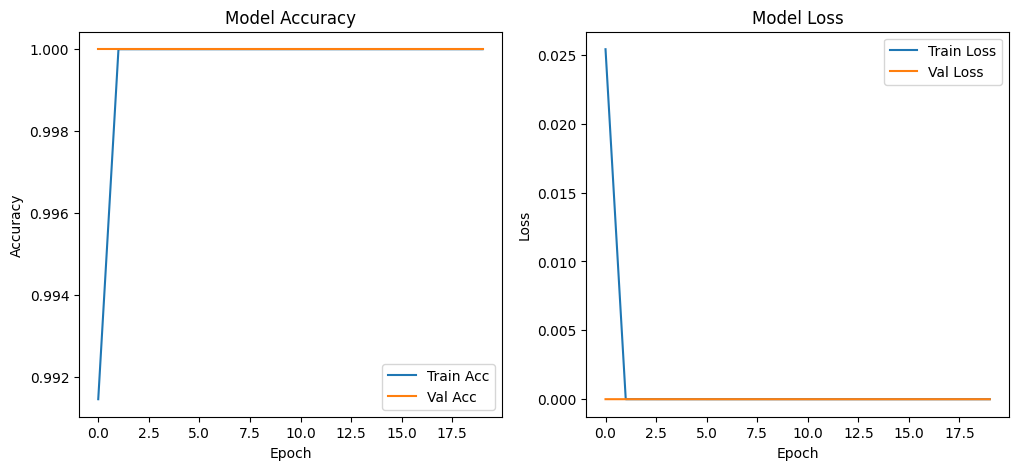

In [ ]:
# -----------------------------------------------------------
# 6. التقييم والحساب والحفظ (الدقيق)
# -----------------------------------------------------------
print("\nجاري حساب النتائج النهائية...")

# 1. تقييم المودل رسمياً (لضمان أننا نستخدم أفضل أوزان تم استرجاعها)
train_loss, train_acc = model.evaluate(X_train, Y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_test, Y_test, verbose=0)

# 2. الحصول على التوقعات
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(Y_test, axis=1)

# 3. حساب مقاييس الأداء التفصيلية
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')

# 4. طباعة النتائج
print("-" * 30)
print(f"✅ Final Test Accuracy (Val_Acc): {val_acc:.4f}")
print(f"✅ Training Accuracy (Train_Acc): {train_acc:.4f}")
print(f"⚠️ Final Test Loss (Val_Loss):    {val_loss:.4f}")
print(f"⚠️ Training Loss (Train_Loss):    {train_loss:.4f}")
print(f"🔹 F1 Score:  {f1:.4f}")
print(f"🔹 Precision: {precision:.4f}")
print(f"🔹 Recall:    {recall:.4f}")
print("-" * 30)

# 5. حفظ النتائج في Excel
results_data = {
    'Metric': ['F1_Score', 'Recall', 'Precision', 'Val_Acc (Test)', 'Train_Acc', 'Val_Loss', 'Train_Loss'],
    'Value': [f1, recall, precision, val_acc, train_acc, val_loss, train_loss]
}
df_results = pd.DataFrame(results_data)
df_results.to_excel(os.path.join(BASE_PATH, 'Training_Results_Detailed.xlsx'), index=False)
print("تم حفظ ملف النتائج: Training_Results_Detailed.xlsx")

# 6. رسم منحنيات التعلم
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.savefig(os.path.join(BASE_PATH, 'learning_curves.png'))
plt.show()

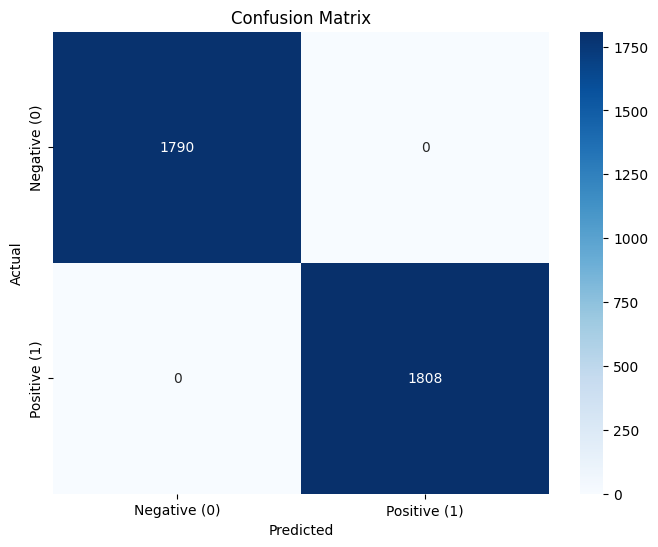


تم الانتهاء! جميع الملفات والصور محفوظة.


In [ ]:
# 7. رسم مصفوفة الارتباك
# تحديد التسميات تلقائياً بناءً على عدد الفئات
unique_labels = sorted(list(set(y_true_classes)))
if len(unique_labels) == 3:
    labels = ['Negative (0)', 'Neutral (1)', 'Positive (2)'] # تعديل حسب ترتيب التشفير لديك
elif len(unique_labels) == 2:
    labels = ['Negative (0)', 'Positive (1)']
else:
    labels = [str(i) for i in unique_labels]

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig(os.path.join(BASE_PATH, 'confusion_matrix.png'))
plt.show()

print("\nتم الانتهاء! جميع الملفات والصور محفوظة.")

In [ ]:
from google.colab import files
import os

# 1. خطوة حفظ المودل النهائي يدوياً (لضمان وجود نسخة أخيرة)
# نحفظه باسم final_model.keras
model.save(os.path.join(BASE_PATH, 'final_model.keras'))
print("✅ تم حفظ المودل النهائي في الدرايف.")

# 2. قائمة الملفات التي سيتم تحميلها لحاسوبك
files_to_download = [
    'Training_Results.xlsx',      # ملف النتائج (تأكد أن الاسم يطابق ما حفظته سابقاً)
    'confusion_matrix.png',       # صورة المصفوفة
    'best_model.keras',           # أفضل نسخة للمودل (من الـ Checkpoint)
    'tokenizer.pickle'            # <--- ⚠️ مهم جداً: هذا ملف قاموس الكلمات
]

print("جاري تحميل الملفات إلى جهازك...")

for file_name in files_to_download:
    file_path = os.path.join(BASE_PATH, file_name)

    if os.path.exists(file_path):
        print(f"⬇️ جاري تحميل: {file_name} ...")
        files.download(file_path)
    else:
        print(f"⚠️ الملف غير موجود: {file_name} (تأكد من تشغيل كود التدريب أولاً)")

✅ تم حفظ المودل النهائي في الدرايف.
جاري تحميل الملفات إلى جهازك...
⬇️ جاري تحميل: Training_Results.xlsx ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ جاري تحميل: confusion_matrix.png ...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ جاري تحميل: tokenizer.pickle ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>